In [30]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import hog
from skimage import io, color
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [47]:
def augment_image(img):
    angle = random.uniform(-45, 45)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    max_shift = 0.1
    tx = random.uniform(-max_shift, max_shift) * w
    ty = random.uniform(-max_shift, max_shift) * h
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    factor = random.uniform(0.7, 1.3)  
    img = np.clip(img * factor, 0, 1)

    return img


In [52]:
DATA_DIR = "train"
classes = {
    "rabbit": 1,
    "not rabbit": 0
}

data = []
labels = []
filenames = []

TARGET_SIZE = (512, 512) 

In [53]:

for cls_name, cls_label in classes.items():
    folder = os.path.join(DATA_DIR, cls_name)
    for fname in os.listdir(folder):
        if not fname.lower().endswith(("jpg", "jpeg", "png")):
            continue

        path = os.path.join(folder, fname)

        img = io.imread(path)
        img = cv2.resize(img, TARGET_SIZE)

        if len(img.shape) == 3:
            img = color.rgb2gray(img)

        img = img.astype('float32')
        hog_features = hog(
            img,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True
        )
        import numpy as np
        if np.isnan(hog_features).any():
            print("Есть ли NaN в HOG:", np.isnan(hog_features).any())

        data.append(hog_features)
        labels.append(cls_label)
        filenames.append(fname)
    


In [54]:
df = pd.DataFrame(data)
df["label"] = labels
df["filename"] = filenames

print("Размерность таблицы:", df.shape)
print(df.head())


X = df.drop(["label", "filename"], axis=1).values
y = df["label"].values
X_train, X_test, y_train, y_test, fn_train, fn_test = train_test_split(
    X, y, filenames, test_size=0.2, random_state=123, stratify=y
)

models = {
    "SVM (RBF)": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Logistic Regression": LogisticRegression(max_iter=2000)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print("=== Модель:", name, "===")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))

print("Итоговое сравнение accuracy:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

Размерность таблицы: (210, 34598)
          0         1         2         3         4         5         6  \
0  0.242186  0.099077  0.036603  0.059240  0.119217  0.202394  0.075214   
1  0.303973  0.079425  0.049097  0.046550  0.117954  0.059645  0.136939   
2  0.320196  0.320196  0.298432  0.014672  0.024616  0.005412  0.011590   
3  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
4  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

          7         8         9  ...     34588     34589     34590     34591  \
0  0.119695  0.282244  0.062142  ...  0.091325  0.017830  0.016340  0.174236   
1  0.182207  0.303973  0.258248  ...  0.036489  0.115779  0.277338  0.277338   
2  0.094586  0.320196  0.207737  ...  0.097291  0.115648  0.230105  0.198717   
3  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
4  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   

      34592     34593     34594   

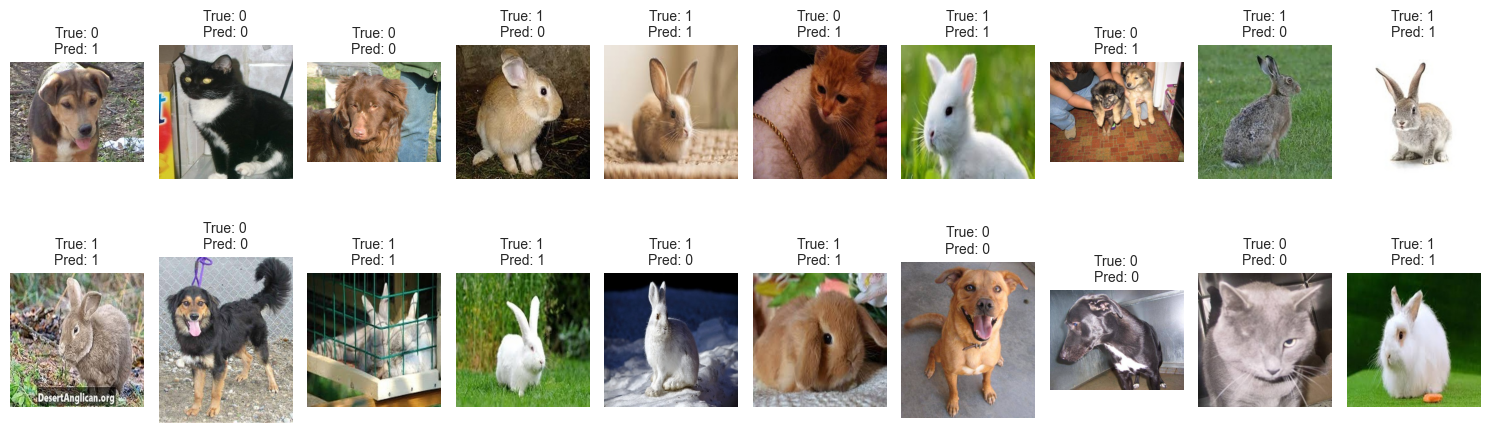

In [55]:

import matplotlib.pyplot as plt
import random
import cv2

sample_indices = random.sample(range(len(X_test)), 20)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(sample_indices):
    filename = fn_test[idx]      
    label_true = y_test[idx]

    # Путь к файлу
    folder = "train/rabbit" if label_true == 1 else "train/not rabbit"
    img_path = os.path.join(folder, filename).replace("_aug1", "").replace("_aug0", "")

    # Загружаем изображение
    img = cv2.imread(img_path)
    if img is None:
        print("Не удалось загрузить:", img_path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pred = model.predict([X_test[idx]])[0]

    plt.subplot(2, 10, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {label_true}\nPred: {pred}", fontsize=10)

plt.tight_layout()
plt.show()

In [56]:
DATA_DIR = "train2"

In [57]:



for cls_name, cls_label in classes.items():
    folder = os.path.join(DATA_DIR, cls_name)
    for fname in os.listdir(folder):
        if not fname.lower().endswith(("jpg", "jpeg", "png")):
            continue

        path = os.path.join(folder, fname)


        img = io.imread(path)
        img = cv2.resize(img, TARGET_SIZE)

        if len(img.shape) == 3:
            img = color.rgb2gray(img)

        img = img.astype('float32')
        hog_features = hog(
            img,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True
        )
        import numpy as np
        if np.isnan(hog_features).any():
            print("Есть ли NaN в HOG:", np.isnan(hog_features).any())

        data.append(hog_features)
        labels.append(cls_label)
        filenames.append(fname)
        
        for _ in range(2):  
            aug_img = augment_image(img)
            hog_features_aug = hog(
                aug_img,
                orientations=9,
                pixels_per_cell=(16, 16),
                cells_per_block=(2, 2),
                block_norm='L2-Hys',
                transform_sqrt=True
            )
            data.append(hog_features_aug)
            labels.append(cls_label)
            filenames.append(fname + "_aug" + str(_))

In [58]:
df = pd.DataFrame(data)
df["label"] = labels
df["filename"] = filenames

print("Размерность таблицы:", df.shape)
print(df.head())
df.info()
# ---- 3. Train/Test ----
X = df.drop(["label", "filename"], axis=1).values
y = df["label"].values
X_train, X_test, y_train, y_test, fn_train, fn_test = train_test_split(
    X, y, filenames, test_size=0.2, random_state=123, stratify=y
)

models = {
    "SVM (RBF)": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Logistic Regression": LogisticRegression(max_iter=2000)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print("\n=== Модель:", name, "===")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))

print("\nИтоговое сравнение accuracy:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

Размерность таблицы: (933, 34598)
          0         1         2         3         4         5         6  \
0  0.242186  0.099077  0.036603  0.059240  0.119217  0.202394  0.075214   
1  0.303973  0.079425  0.049097  0.046550  0.117954  0.059645  0.136939   
2  0.320196  0.320196  0.298432  0.014672  0.024616  0.005412  0.011590   
3  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
4  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

          7         8         9  ...     34588     34589     34590     34591  \
0  0.119695  0.282244  0.062142  ...  0.091325  0.017830  0.016340  0.174236   
1  0.182207  0.303973  0.258248  ...  0.036489  0.115779  0.277338  0.277338   
2  0.094586  0.320196  0.207737  ...  0.097291  0.115648  0.230105  0.198717   
3  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
4  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   

      34592     34593     34594   

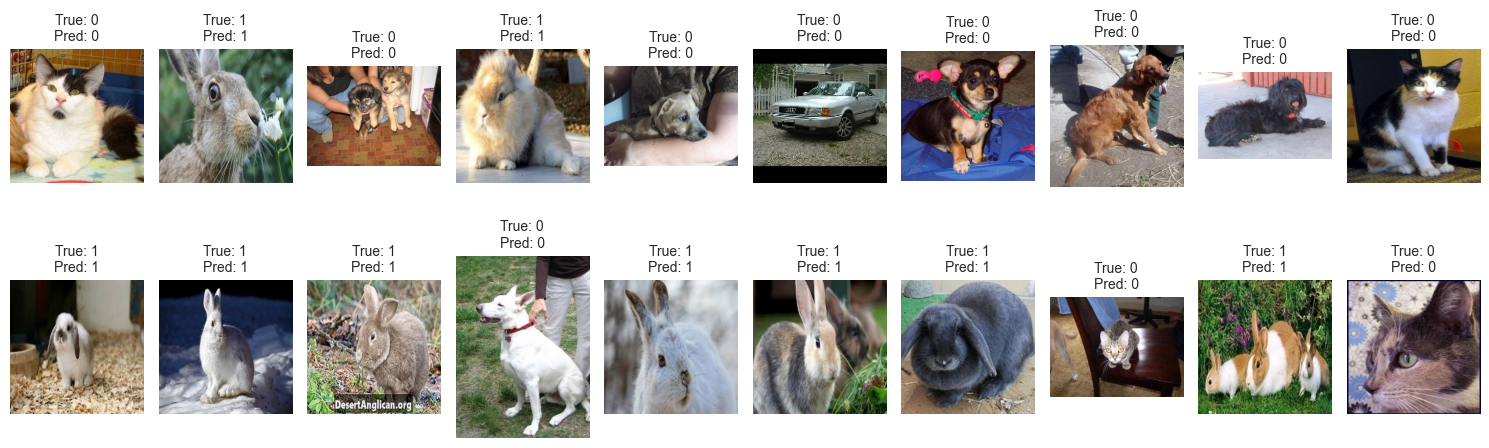

In [67]:

import matplotlib.pyplot as plt
import random
import cv2

sample_indices = random.sample(range(len(X_test)), 20)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(sample_indices):
    filename = fn_test[idx]      
    label_true = y_test[idx]

    folder = "train2/rabbit" if label_true == 1 else "train2/not rabbit"
    img_path = os.path.join(folder, filename).replace("_aug1", "").replace("_aug0", "")

    img = cv2.imread(img_path)
    if img is None:
        print("Не удалось загрузить:", img_path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pred = model.predict([X_test[idx]])[0]

    plt.subplot(2, 10, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {label_true}\nPred: {pred}", fontsize=10)

plt.tight_layout()
plt.show()